#### validation dataset generation   

In [1]:
import torch
import numpy as np
from glob import glob
import rasterio as rio
from notebooks import config
from pyrsimg import img2patch
from pyrsimg import imsShow, imgShow
from torchvision.transforms import v2 


In [6]:
patch_size = 512  ## base patch size
# ## valset
paths_valset = list(zip(config.paths_scene_val, config.paths_truth_val))
print(len(paths_valset))
paths_valset[4]


43


('data/dset/scene/scene_nor/l5/l5_scene_21.tif',
 'data/dset/truth/truth_tif/l5/l5_scene_21_truth_final.tif')

In [ ]:
## generate validation patches (include patch,dem,truth)
dset_patch_list = []
dset_start_list = []
dset_list = []       ## [patches, higher_patches]
for path_scene,  path_truth in paths_valset:
    print(path_scene)
    scene_val_arr = rio.open(path_scene).read()   ## (C, H, W)
    truth_val_arr = rio.open(path_truth).read(1)
    size_global = scene_val_arr.shape[1:]
    ## image to patches
    scene_truth_arr = np.concatenate([scene_val_arr, 
                                        truth_val_arr[np.newaxis, ...]], 
                                        axis=0)
    scene_truth_arr_ = torch.from_numpy(scene_truth_arr).to(dtype=torch.float16)
    img2patches = img2patch(img = scene_truth_arr_.numpy().transpose(1,2,0), 
                            patch_size = patch_size, 
                            edge_overlay = 40,  ## 40,100 for patch_512, patch_1024
                            drop_last=True)
    patch_truth_list = img2patches.toPatch()
    patch_lat_list = [scene_val_arr]*len(patch_truth_list)
    print(len(patch_truth_list))
    dset_list.extend(patch_truth_list)
    # break
print('num of patches:', len(dset_list))


data/dset/scene/scene_nor/l5/l5_scene_01.tif
4
data/dset/scene/scene_nor/l5/l5_scene_06.tif
4
data/dset/scene/scene_nor/l5/l5_scene_11.tif
4
data/dset/scene/scene_nor/l5/l5_scene_16.tif
4
data/dset/scene/scene_nor/l5/l5_scene_21.tif
4
data/dset/scene/scene_nor/l5/l5_scene_26.tif
6
data/dset/scene/scene_nor/l7/l7_scene_01.tif
4
data/dset/scene/scene_nor/l7/l7_scene_06.tif
4
data/dset/scene/scene_nor/l7/l7_scene_11.tif
4
data/dset/scene/scene_nor/l7/l7_scene_16.tif
4
data/dset/scene/scene_nor/l7/l7_scene_21.tif
4
data/dset/scene/scene_nor/l7/l7_scene_27.tif
4
data/dset/scene/scene_nor/l8/l8_scene_02.tif
16
data/dset/scene/scene_nor/l8/l8_scene_07.tif
6
data/dset/scene/scene_nor/l8/l8_scene_12.tif
6
data/dset/scene/scene_nor/l8/l8_scene_17.tif
6
data/dset/scene/scene_nor/l8/l8_scene_22.tif
4
data/dset/scene/scene_nor/l8/l8_scene_27.tif
4
data/dset/scene/scene_nor/l9/l9_scene_02.tif
9
data/dset/scene/scene_nor/l9/l9_scene_07.tif
12
data/dset/scene/scene_nor/l9/l9_scene_12.tif
16
data/dset/

In [8]:
'''----  save multiscale patch data  ----'''
dir_valset = f'data/dset/valset/patch_{patch_size}'
for id_patch, patch_ptruth in enumerate(dset_list):
    print(id_patch)
    patch_ptruth_ = torch.from_numpy(patch_ptruth).permute(2,0,1)  ## (C, H, W)
    ## save as float16 to save space
    patch_ptruth_ = patch_ptruth_.to(dtype=torch.float16)
    path_save = dir_valset+f'/patch_ptruth_' + str(id_patch).rjust(4,'0')+'.pth'
    print(path_save)
    torch.save((patch_ptruth_), path_save)
    # break


0
data/dset/valset/patch_512/patch_ptruth_0000.pth
1
data/dset/valset/patch_512/patch_ptruth_0001.pth
2
data/dset/valset/patch_512/patch_ptruth_0002.pth
3
data/dset/valset/patch_512/patch_ptruth_0003.pth
4
data/dset/valset/patch_512/patch_ptruth_0004.pth
5
data/dset/valset/patch_512/patch_ptruth_0005.pth
6
data/dset/valset/patch_512/patch_ptruth_0006.pth
7
data/dset/valset/patch_512/patch_ptruth_0007.pth
8
data/dset/valset/patch_512/patch_ptruth_0008.pth
9
data/dset/valset/patch_512/patch_ptruth_0009.pth
10
data/dset/valset/patch_512/patch_ptruth_0010.pth
11
data/dset/valset/patch_512/patch_ptruth_0011.pth
12
data/dset/valset/patch_512/patch_ptruth_0012.pth
13
data/dset/valset/patch_512/patch_ptruth_0013.pth
14
data/dset/valset/patch_512/patch_ptruth_0014.pth
15
data/dset/valset/patch_512/patch_ptruth_0015.pth
16
data/dset/valset/patch_512/patch_ptruth_0016.pth
17
data/dset/valset/patch_512/patch_ptruth_0017.pth
18
data/dset/valset/patch_512/patch_ptruth_0018.pth
19
data/dset/valset/pa

62
data/dset/valset/patch_512/patch_ptruth_0062.pth
63
data/dset/valset/patch_512/patch_ptruth_0063.pth
64
data/dset/valset/patch_512/patch_ptruth_0064.pth
65
data/dset/valset/patch_512/patch_ptruth_0065.pth
66
data/dset/valset/patch_512/patch_ptruth_0066.pth
67
data/dset/valset/patch_512/patch_ptruth_0067.pth
68
data/dset/valset/patch_512/patch_ptruth_0068.pth
69
data/dset/valset/patch_512/patch_ptruth_0069.pth
70
data/dset/valset/patch_512/patch_ptruth_0070.pth
71
data/dset/valset/patch_512/patch_ptruth_0071.pth
72
data/dset/valset/patch_512/patch_ptruth_0072.pth
73
data/dset/valset/patch_512/patch_ptruth_0073.pth
74
data/dset/valset/patch_512/patch_ptruth_0074.pth
75
data/dset/valset/patch_512/patch_ptruth_0075.pth
76
data/dset/valset/patch_512/patch_ptruth_0076.pth
77
data/dset/valset/patch_512/patch_ptruth_0077.pth
78
data/dset/valset/patch_512/patch_ptruth_0078.pth
79
data/dset/valset/patch_512/patch_ptruth_0079.pth
80
data/dset/valset/patch_512/patch_ptruth_0080.pth
81
data/dset

### load data and check

In [ ]:
## load data
paths_valset = sorted(glob('data/dset/valset/patch_512/*'))
valset_list = [torch.load(path, weights_only=False) for path in paths_valset]
print(len(valset_list))  


35


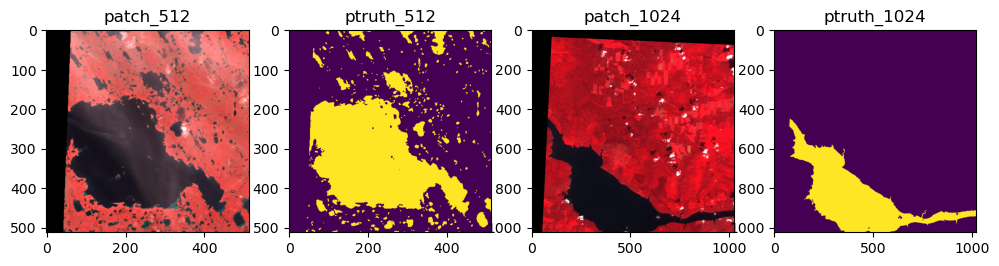

In [ ]:
id = np.random.randint(0, len(valset_list))
patch_ptruth = valset_list[id]
patch, ptruth = patch_ptruth[0:6, :, :], patch_ptruth[6:7, :, :]
imgs_name = ['patch', 'ptruth']  
clip_list = [2, 0]  
col_bands_list = [(3,2,1), (0,0,0)]
imsShow(img_list=[patch.numpy().transpose(1,2,0), 
                  ptruth.numpy().transpose(1,2,0)], 
            img_name_list=imgs_name,
            clip_list=clip_list, 
            color_bands_list=col_bands_list,
            figsize=(7, 3)); 
